# Dimensionality reduction

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
# ----------------------------------
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import plotting_utils as pu
import matplotlib as mpl
#----------------------------------
from sklearn.decomposition import PCA
from deeptime.decomposition import TICA

class PCAWrapper:
    """
    Small wrapper that gives sklearn PCA a deeptime-like API:
    fit(...).fetch_model().transform(...).
    """
    def __init__(self, dim: int):
        self.model = PCA(n_components=dim)

    def fit(self, traj):
        self.model.fit(traj)
        return self

    def fetch_model(self):
        return self.model

    def transform(self, X):
        return self.model.transform(X)
    
#----------------------------------
data_folder = "../data/"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
### Loading trajectiories

In [13]:
# set 1: distances

#distances = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float)
distances = np.load("../intermediate_outputs/distances_filtered.npy")
print("Data shape", distances.shape) # [nm] nanometers
print("Data size (MB)", distances.nbytes / (10**6))

# set 2: dihedrals
#dihedrals = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
dihedrals = np.load("../intermediate_outputs/dihedrals_filtered.npy")
print("Data shape", dihedrals.shape) # [radians] 
print("Data size (MB)", dihedrals.nbytes / (10**6))

Data shape (1526041, 42)
Data size (MB) 512.749776
Data shape (1526041, 66)
Data size (MB) 805.749648


In [14]:
total_time_micros = 305
time_step_micros =  total_time_micros / distances.shape[0]
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


---
### Exploring tICA at different lagtimes

Lag times (microseconds) [0.0019986356854108113, 0.01998635685410811, 0.19986356854108112, 19.986356854108113]
Lag times (nanoseconds) [1.9986356854108114, 19.98635685410811, 199.86356854108112, 19986.35685410811]


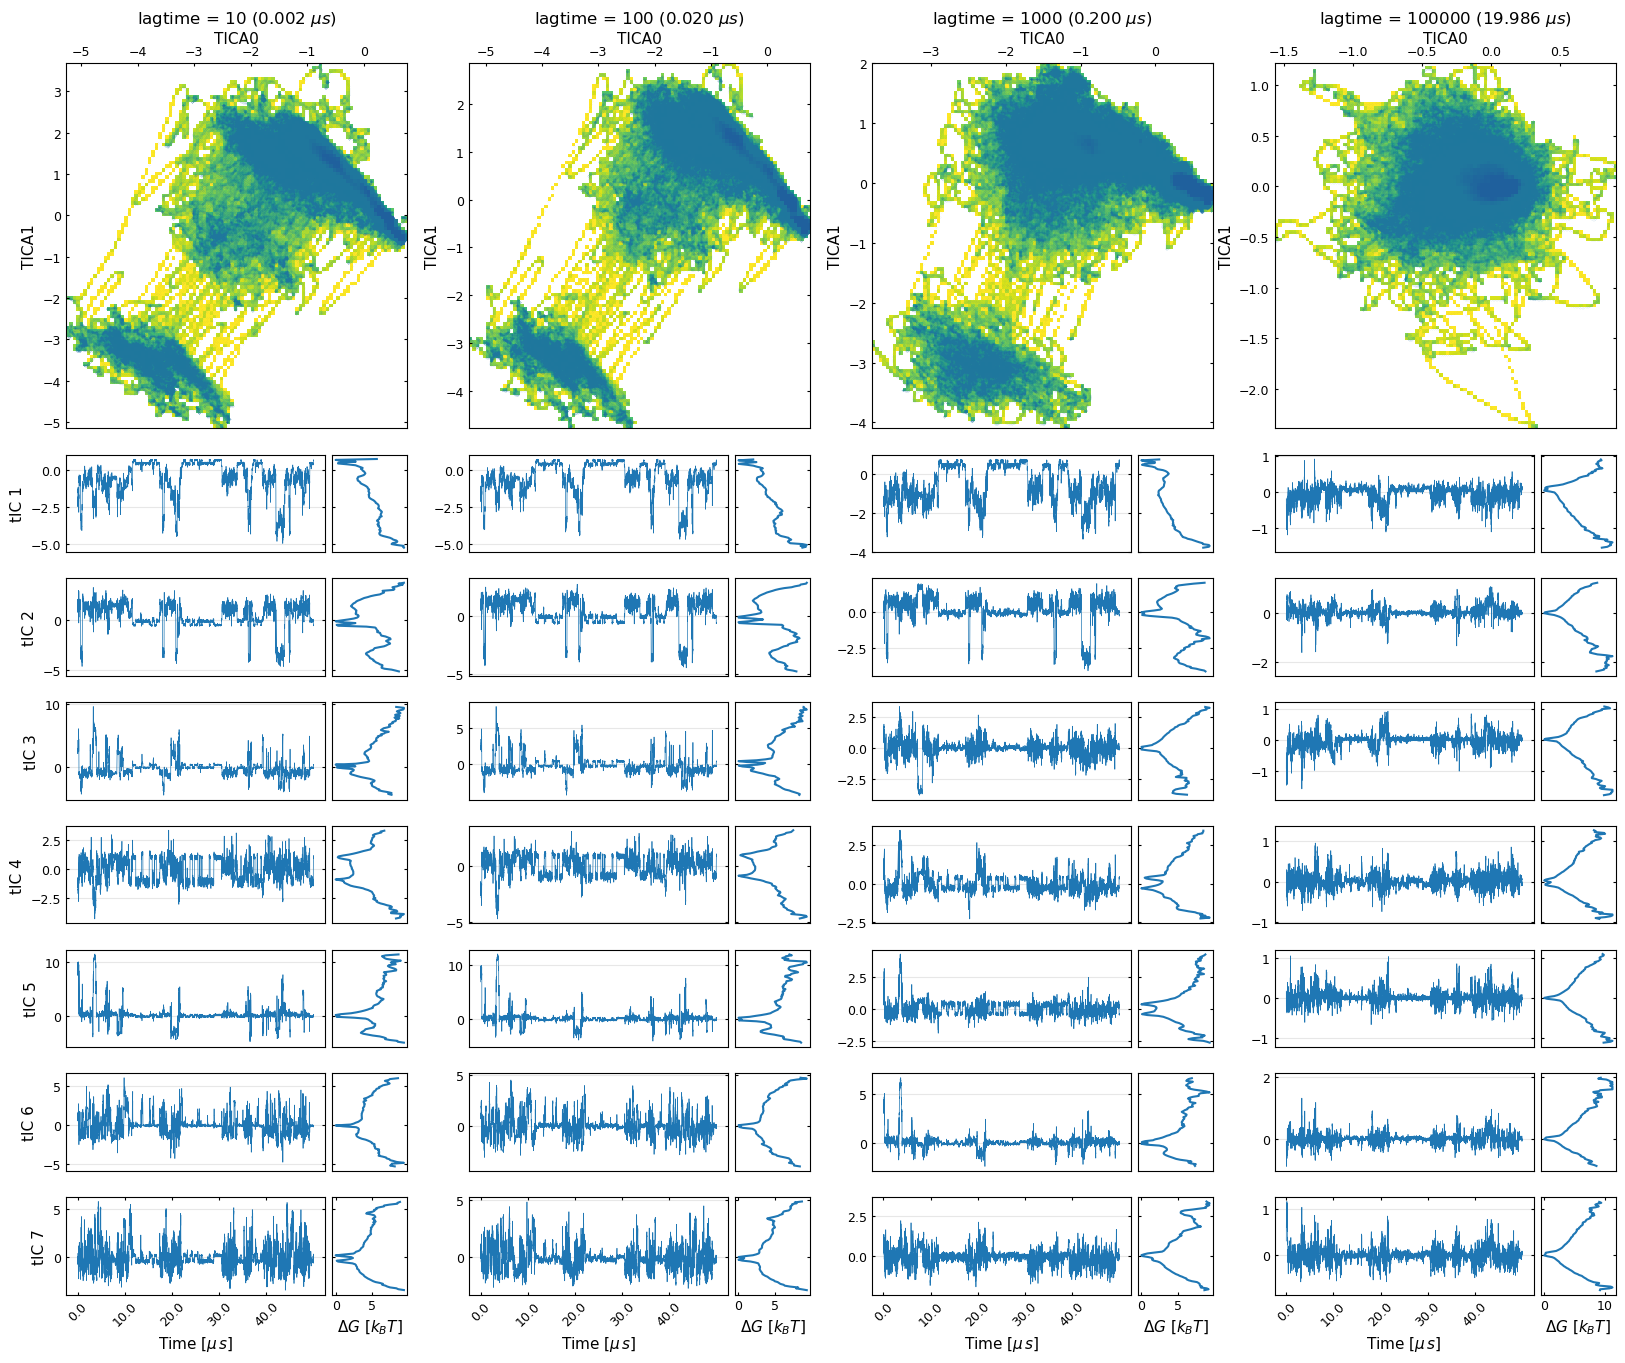

In [15]:
run_lagtime_analysis = True

if run_lagtime_analysis:
    X = dihedrals
    n_tics = 7
    lagtime_array = [10, 100, 1000, 100000] 
    lagtime_microseconds = [lag * time_step_micros for lag in lagtime_array]
    print("Lag times (microseconds)", lagtime_microseconds) # [2, 20, 200, 20000] microseconds
    print("Lag times (nanoseconds)", [lag * time_step_micros * 10**3 for lag in lagtime_array]) # [0.2, 2, 20, 2000] nanoseconds



    ###########################################
    # ----------- Plot specifics --------------

    n_microseconds_show = 50
    tickevery = 10
    n_show = n_microseconds_show * one_microsecond_in_frames
    n_lags = len(lagtime_array)

    fig = plt.figure(figsize=(5* n_lags, 16))

    gs = GridSpec(
        nrows=n_tics + 1,
        ncols=n_lags,
        figure=fig,
        height_ratios=[3] + [0.8] * n_tics,
        hspace=0.2,
        wspace=0.18
    )

    axes = np.empty((n_tics + 1, n_lags), dtype=object)

    for i in range(n_tics + 1):
        for j in range(n_lags):
            axes[i, j] = fig.add_subplot(gs[i, j])   
    ###########################################


    for lagtime in lagtime_array:
        # fit tica
        #############################################
        ticamodel = TICA(lagtime=lagtime, dim=n_tics)
        ticamodel.fit(X)
        tica_traj = ticamodel.transform(X)
        #############################################
        
        # Plot
        if lagtime == lagtime_array[-1]:
            colorbarlabel = r"$F/k_B T$"
        else:        
            colorbarlabel = None
        pu.plot_free_energy_projection(tica_traj, 0, 1, ax = axes[0, lagtime_array.index(lagtime)], axlabel = "TICA", colorbarlabel = colorbarlabel, axtitle = rf"lagtime = {lagtime} ({lagtime_microseconds[lagtime_array.index(lagtime)]:.3f} $\mu s$)")

        for component in range(n_tics):

            j = lagtime_array.index(lagtime)
            ax = axes[1 + component, j]
            x = tica_traj[:n_show, component]
            ax.set_xticks(np.arange(0, n_show, tickevery*one_microsecond_in_frames))
            ax.set_xticklabels(np.arange(0, n_show/one_microsecond_in_frames, tickevery), rotation=45)
            ax.plot(x, lw=0.5)
            if lagtime == lagtime_array[0]:
                ax.set_ylabel(f"tIC {component + 1}")
            else:
                ax.set_ylabel("")
            ax.tick_params(axis="x", labelrotation=45)
            ax.grid(axis="y", alpha=0.3)
            ax_fe = pu.add_1d_free_energy_axis(
                ax=ax,
                x=tica_traj[:, component], #all trajectory for free energy
                bins=100,
                color="C0")
            if component < n_tics - 1:
                ax.set_xticks([])
                ax.set_xlabel("")
                ax_fe.set_xticks([])

            else:
                ax.set_xlabel(r"Time [$\mu\, s$]")
                ax_fe.set_xlabel(r"$\Delta G$ [$k_B T$]")

In [16]:
tica_selected_lagtime_mus = 0.01
tica_selected_lagtime_frames = int(tica_selected_lagtime_mus / time_step_micros)
print("Selected lagtime (frames)", tica_selected_lagtime_frames) # 500 frames

Selected lagtime (frames) 50


---

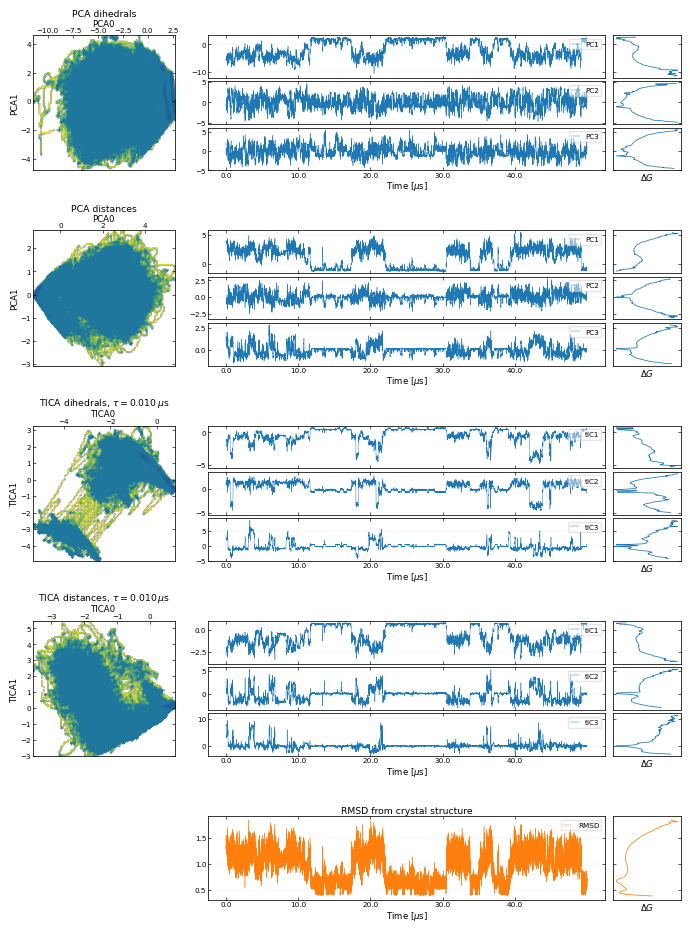

In [17]:

# --------------------------------
# Helper: 1D free-energy profile
# --------------------------------
def plot_1d_free_energy_profile(
    ax,
    x,
    bins=100,
    lw=0.6,
    xlabel=r"$\Delta G$",
    color = None
):
    hist, edges = np.histogram(x, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    with np.errstate(divide="ignore", invalid="ignore"):
        free_energy = -np.log(hist)

    finite = np.isfinite(free_energy)

    if np.any(finite):
        free_energy[finite] -= np.nanmin(free_energy[finite])

    if color is None:
        ax.plot(free_energy, centers, lw=lw)
    else:
        ax.plot(free_energy, centers, lw=lw, color=color)

    ax.set_xlabel(xlabel, labelpad=1)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelleft=False)

    return ax


# --------------------------------
# Figure style for A4 full-page figure
# --------------------------------
plt.rcParams.update({
    "font.size": 6.3,
    "axes.titlesize": 6.7,
    "axes.labelsize": 6.2,
    "xtick.labelsize": 5.4,
    "ytick.labelsize": 5.4,
    "legend.fontsize": 5.8,
    "axes.linewidth": 0.55,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "xtick.major.size": 2.2,
    "ytick.major.size": 2.2,
    "savefig.dpi": 300,
})

# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

# --------------------------------
# Input data
# --------------------------------
X_list = [dihedrals, distances]
feature_name = ["dihedrals", "distances"]

n_components = 5          # number fitted
n_components_show = 3     # number shown as time series

# --------------------------------
# Plot specifics
# --------------------------------
n_microseconds_show = 50
tickevery = 10
n_show = n_microseconds_show * one_microsecond_in_frames

time_ticks_frames = np.arange(
    0,
    n_show,
    tickevery * one_microsecond_in_frames
)

time_tick_labels = np.arange(
    0,
    n_show / one_microsecond_in_frames,
    tickevery
)

# --------------------------------
# Define pipelines
# --------------------------------
pipelines = []

# PCA pipelines
for X, name in zip(X_list, feature_name):
    pipelines.append({
        "method": "PCA",
        "X": X,
        "feature": name,
        "lagtime_frames": None,
        "title": rf"PCA {name}"
    })

# TICA pipelines
for X, name in zip(X_list, feature_name):
    pipelines.append({
        "method": "TICA",
        "X": X,
        "feature": name,
        "lagtime_frames": tica_selected_lagtime_frames,
        "title": rf"TICA {name}, $\tau={tica_selected_lagtime_mus:.3f}\,\mu$s"
    })

n_pipelines = len(pipelines)

# --------------------------------
# Figure layout for A4 portrait page
# --------------------------------
nrows = n_pipelines + 1
ncols = 4

fig = plt.figure(figsize=(7.2, 9.4))

gs = GridSpec(
    nrows=nrows,
    ncols=ncols,
    figure=fig,
    width_ratios=[1.05, 1.0, 1.0, 1.0],
    height_ratios=[1.0] * n_pipelines + [0.62],
    hspace=0.48,
    wspace=0.24
)

# --------------------------------
# Plot one pipeline per row
# --------------------------------
for row, spec in enumerate(pipelines):

    X = spec["X"]
    method = spec["method"]

    # ----------------------------
    # Fit and transform
    # ----------------------------
    if method == "PCA":
        model = PCAWrapper(dim=n_components)
        model.fit(X)
        reduced_traj = model.transform(X)

        axlabel = "PCA"
        component_label = "PC"

    elif method == "TICA":
        model = TICA(
            lagtime=spec["lagtime_frames"],
            dim=n_components
        )
        model.fit(X)
        reduced_traj = model.transform(X)

        axlabel = "TICA"
        component_label = "tIC"

    else:
        raise ValueError(f"Unknown method: {method}")

    # ----------------------------
    # Left column: 2D free-energy projection
    # ----------------------------
    ax_2d = fig.add_subplot(gs[row, 0])

    colorbarlabel = r"$F/k_B T$" if row == n_pipelines - 1 else None

    pu.plot_free_energy_projection(
        reduced_traj,
        0,
        1,
        ax=ax_2d,
        axlabel=axlabel,
        colorbarlabel=colorbarlabel,
        axtitle=spec["title"]
    )

    ax_2d.set_title(spec["title"], fontsize=6.7, pad=2)
    ax_2d.tick_params(
        axis="both",
        labelsize=5.2,
        width=0.45,
        length=2,
        pad=1.2
    )

    ax_2d.set_xlabel(ax_2d.get_xlabel(), labelpad=1)
    ax_2d.set_ylabel(ax_2d.get_ylabel(), labelpad=1)

    for spine in ax_2d.spines.values():
        spine.set_linewidth(0.55)

    # ----------------------------
    # Right block:
    # three stacked time series + separate profile axes
    # spanning columns 1--3
    # ----------------------------
    gs_ts = gs[row, 1:].subgridspec(
        nrows=n_components_show,
        ncols=2,
        width_ratios=[1.0, 0.17],
        hspace=0.08,
        wspace=0.035
    )

    for component in range(n_components_show):

        ax = fig.add_subplot(gs_ts[component, 0])
        ax_prof = fig.add_subplot(gs_ts[component, 1], sharey=ax)

        x_show = reduced_traj[:n_show, component]
        x_all = reduced_traj[:, component]

        ax.plot(x_show, lw=0.32, label=f"{component_label}{component + 1}")

        ax.legend(loc="upper right", fontsize=5.2, frameon=True, framealpha=0.5, handlelength=1.2, handleheight=0.8, borderpad=0.3, labelspacing=0.2)

        ax.grid(axis="y", alpha=0.25, lw=0.35)

        ax.set_xticks(time_ticks_frames)
        ax.set_xticklabels(time_tick_labels, rotation=0)

        if row == n_pipelines - 1 and component == n_components_show - 1:
            ax_prof.set_xlabel(r"$\Delta G$")
        else:
            ax_prof.set_xlabel("")

        ax.tick_params(
            axis="both",
            labelsize=5.2,
            width=0.45,
            length=2,
            pad=1.2
        )

        plot_1d_free_energy_profile(
            ax=ax_prof,
            x=x_all,
            bins=100,
            lw=0.55,
            xlabel=r"$\Delta G$"
        )

        ax_prof.tick_params(
            axis="both",
            labelsize=5.2,
            width=0.45,
            length=2,
            pad=1.2
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.55)

        for spine in ax_prof.spines.values():
            spine.set_linewidth(0.55)

        if component < n_components_show - 1:
            ax.set_xlabel("")
            ax.set_xticklabels([])
            ax_prof.set_xlabel("")
        else:
            ax.set_xlabel(r"Time [$\mu$s]", labelpad=1)
            ax_prof.set_xlabel(r"$\Delta G$", labelpad=1)

# --------------------------------
# Bottom row: RMSD time series + profile
# First column deliberately left empty.
# --------------------------------
rmsd_row = n_pipelines

ax_empty = fig.add_subplot(gs[rmsd_row, 0])
ax_empty.axis("off")

gs_rmsd = gs[rmsd_row, 1:].subgridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.0, 0.17],
    wspace=0.035
)

ax_rmsd = fig.add_subplot(gs_rmsd[0, 0])
ax_rmsd_prof = fig.add_subplot(gs_rmsd[0, 1], sharey=ax_rmsd)

rmsd_show = rmsd[:n_show]

ax_rmsd.plot(rmsd_show, lw=0.32, label="RMSD", color = "tab:orange")
ax_rmsd.legend(loc="upper right", fontsize=5.2, frameon=True, framealpha=0.5, handlelength=1.2, handleheight=0.8, borderpad=0.3, labelspacing=0.2)

ax_rmsd.set_xlabel(r"Time [$\mu$s]", labelpad=1)
ax_rmsd.set_title("RMSD from crystal structure", fontsize=6.7, pad=2)

ax_rmsd.set_xticks(time_ticks_frames)
ax_rmsd.set_xticklabels(time_tick_labels, rotation=0)

ax_rmsd.grid(axis="y", alpha=0.25, lw=0.35)

ax_rmsd.tick_params(
    axis="both",
    labelsize=5.2,
    width=0.45,
    length=2,
    pad=1.2
)

plot_1d_free_energy_profile(
    ax=ax_rmsd_prof,
    x=rmsd,
    bins=100,
    lw=0.55,
    color = "tab:orange",
    xlabel=r"$\Delta G$"
)

ax_rmsd_prof.tick_params(
    axis="both",
    labelsize=5.2,
    width=0.45,
    length=2,
    pad=1.2
)

for ax in [ax_rmsd, ax_rmsd_prof]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.55)

# --------------------------------
# Final layout and saving
# --------------------------------
fig.subplots_adjust(
    left=0.075,
    right=0.975,
    bottom=0.055,
    top=0.975
)



fig.savefig(
    "../output_figures/RMSD_reduced_projection_A4.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### Performing dim. reduction with the selected hyperparams 

In [7]:
tica_dim_distances = 5
tica_dim_dihedrals = 5
pca_dim_distances = 5
pca_dim_dihedrals = 5

# set 1: distances
tica_model = TICA(lagtime = tica_selected_lagtime_frames, dim = tica_dim_distances).fit(distances)
tica_distances = tica_model.transform(distances)
pca_distances = PCA(n_components = pca_dim_distances).fit_transform(distances)

# set 2: dihedrals
tica_model = TICA(lagtime = tica_selected_lagtime_frames, dim = tica_dim_dihedrals).fit(dihedrals)
tica_dihedrals = tica_model.transform(dihedrals)
pca_dihedrals = PCA(n_components = pca_dim_dihedrals).fit_transform(dihedrals)

# save the TICA and PCA features for later use
np.save(f"../intermediate_outputs/dimred/tica_lag_{tica_selected_lagtime_frames}_dim_{tica_dim_dihedrals}_dihedrals.npy", tica_dihedrals)
np.save(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy", pca_dihedrals)
np.save(f"../intermediate_outputs/dimred/tica_lag_{tica_selected_lagtime_frames}_dim_{tica_dim_distances}_distances.npy", tica_distances)
np.save(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy", pca_distances)

---

# Plot of free energy projection

In [8]:
tica_lag = 500 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 5
pca_dim_distances = 5
pca_dim_dihedrals = 5


tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


In [9]:
from scipy.ndimage import gaussian_filter

# ---------------------------------------------------------------------------
# Fast histogram-based smoothed FES
# ---------------------------------------------------------------------------
def compute_fes_fast(
    traj,
    component_x=0,
    component_y=1,
    nbins=100,
    sigma=1.2,
    padding=0.02,
    eps=1e-12
):
    """
    Fast approximation to a KDE free-energy surface.

    Uses a 2D histogram followed by Gaussian smoothing.
    This is much faster than scipy.stats.gaussian_kde for large trajectories.

    Parameters
    ----------
    traj : ndarray, shape (n_frames, n_features)
        Input trajectory/projection.
    component_x, component_y : int
        Components to project onto.
    nbins : int
        Number of bins along each axis.
    sigma : float
        Gaussian smoothing width in bins.
        Larger values give smoother contours.
    padding : float
        Fractional padding added to x/y limits.
    eps : float
        Small floor to avoid log(0).

    Returns
    -------
    xx, yy : ndarray
        Meshgrid of bin centers.
    F : ndarray
        Free energy surface, shifted so min(F)=0.
    """

    x = traj[:, component_x]
    y = traj[:, component_y]

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)

    dx = xmax - xmin
    dy = ymax - ymin

    xmin -= padding * dx
    xmax += padding * dx
    ymin -= padding * dy
    ymax += padding * dy

    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=nbins,
        range=[[xmin, xmax], [ymin, ymax]],
        density=True
    )

    # Smooth the density estimate
    H_smooth = gaussian_filter(H, sigma=sigma)

    # Avoid log(0)
    H_smooth = np.maximum(H_smooth, eps)

    F = -np.log(H_smooth)
    F -= np.nanmin(F)

    # Bin centers
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    xx, yy = np.meshgrid(xcenters, ycenters, indexing="ij")

    return xx, yy, F

In [10]:
nbins_linear = 100

trajectories = [
    tica_distances,
    pca_distances,
    tica_dihedrals,
    pca_dihedrals
]

Fs = []
grids = []

component_x = 0
component_y = 1

for i, traj in enumerate(trajectories):
    print(f"Computing FES for trajectory {trajectories_labels[i]}...")
    xx, yy, F = compute_fes_fast(
        traj,
        component_x=component_x,
        component_y=component_y,
        nbins=nbins_linear
    )
    grids.append((xx, yy))
    Fs.append(F)


Computing FES for trajectory tica_distances...
Computing FES for trajectory pca_distances...
Computing FES for trajectory tica_dihedrals...
Computing FES for trajectory pca_dihedrals...


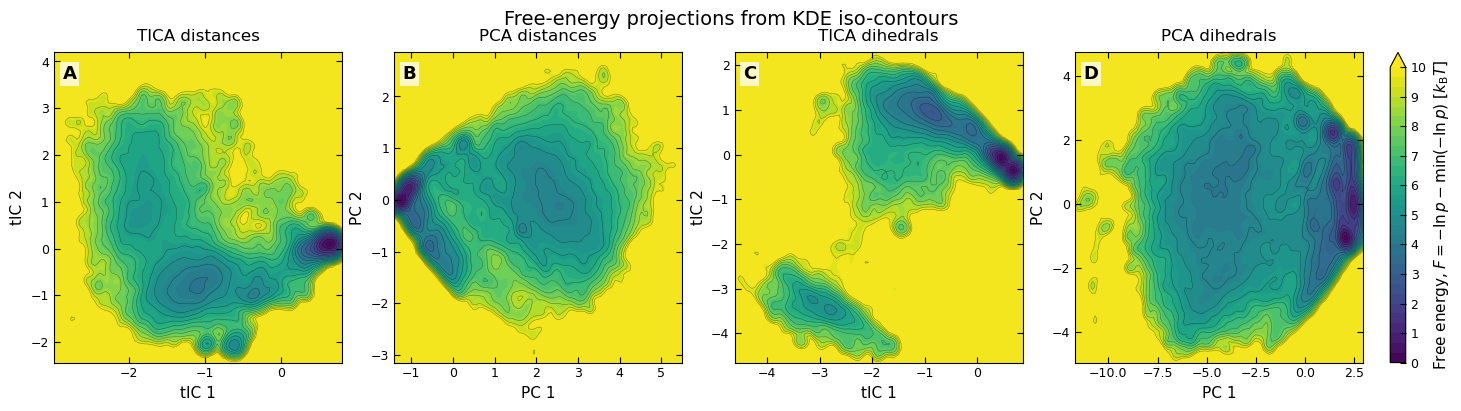

In [11]:
# ---------------------------------------------------------------------------
# Report-quality iso-contour FES plot

# Free energy range
vmin = 0
vmax = 10

# Filled-contour and line-contour levels
levels_filled = np.linspace(vmin, vmax, 31)
levels_lines = np.arange(vmin, vmax + 0.5, 0.5)

# Matplotlib publication settings
mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

titles = [
    "TICA distances",
    "PCA distances",
    "TICA dihedrals",
    "PCA dihedrals"
]

xlabels = [
    "tIC 1",
    "PC 1",
    "tIC 1",
    "PC 1"
]

ylabels = [
    "tIC 2",
    "PC 2",
    "tIC 2",
    "PC 2"
]

panel_labels = ["A", "B", "C", "D"]

# ---------------------------------------------------------------------------
# Figure

fig, axes = plt.subplots(
    1, 4,
    figsize=(14.5, 3.8),
    constrained_layout=True
)

axes = axes.flatten()

cmap = "viridis"

for ax, title, xlabel, ylabel, F, (xx, yy), panel in zip(
    axes, titles, xlabels, ylabels, Fs, grids, panel_labels
):
    # Clip high free energies so all panels share the same visual scale
    F_plot = np.clip(F, vmin, vmax)

    im = ax.contourf(
        xx,
        yy,
        F_plot,
        levels=levels_filled,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extend="max"
    )

    ax.contour(
        xx,
        yy,
        F_plot,
        levels=levels_lines,
        colors="k",
        linewidths=0.35,
        alpha=0.45
    )

    ax.set_title(title, pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Panel label
    ax.text(
        0.03,
        0.96,
        panel,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=2.0
        )
    )

    # Better axis appearance
    ax.tick_params(length=4, width=0.8)
    ax.set_aspect("auto")

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)

cbar.set_label(r"Free energy, $F = -\ln p - \min(-\ln p)$ [$k_\mathrm{B}T$]")
cbar.set_ticks(np.arange(vmin, vmax + 1, 1))
cbar.ax.tick_params(length=4, width=0.8)

fig.suptitle(
    "Free-energy projections from KDE iso-contours",
    y=1.04
)

# ---------------------------------------------------------------------------
# Save both raster and vector versions

fig.savefig(
    "../output_figures/free_energy_projection_report.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/free_energy_projection_report.pdf",
    bbox_inches="tight"
)

plt.show()